256 517 1146 1512 2000
306.12932330827067
354 152 400 201 2000
277.5436090225564
1019 127 1077 199 2000
276.8418546365915
0 86 97 173 2000
267.5365914786968


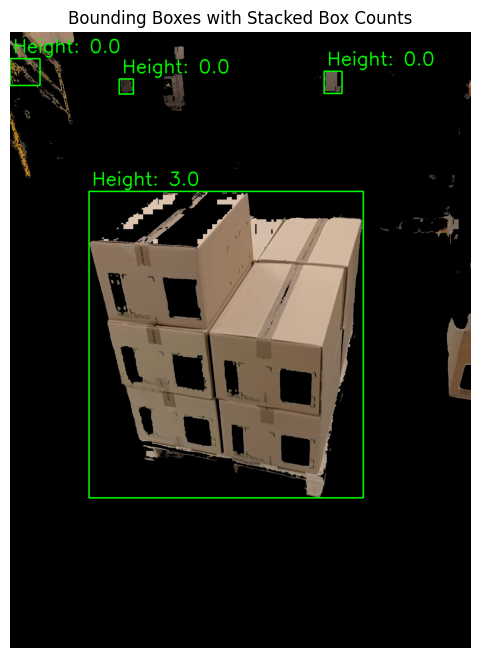

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import fcluster, linkage
# Import find_peaks correctly
from scipy.signal import find_peaks

# Load the image
image_path = "/home/ediss4/sarosh/personal/ws/WhatsApp Image 2025-02-14 at 12.10.21 (1).jpeg"
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Could not load image from {image_path}")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur to reduce noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Detect edges using Canny Edge Detection
edges = cv2.Canny(blurred, 50, 150)

# Apply Morphological Closing to connect broken edges
kernel = np.ones((3, 3), np.uint8)
closed_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

# Find contours
contours, _ = cv2.findContours(closed_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Get bounding boxes from contours
bounding_boxes = []
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    
    # Filter based on aspect ratio and size
    aspect_ratio = w / float(h)
    if 0.8 <= aspect_ratio <= 1.2 and w > 30 and h > 30:  # Adjust size constraints
        bounding_boxes.append((x, y, x + w, y + h))  # Store (x1, y1, x2, y2)

# Function to merge overlapping bounding boxes
def merge_bounding_boxes(boxes):
    merged = []
    while boxes:
        x1, y1, x2, y2 = boxes.pop(0)  # Take the first box
        merged_box = (x1, y1, x2, y2)
        
        i = 0
        while i < len(boxes):
            bx1, by1, bx2, by2 = boxes[i]
            
            # Check if boxes overlap
            if not (bx2 < x1 or bx1 > x2 or by2 < y1 or by1 > y2):  
                # Merge boxes
                merged_box = (
                    min(merged_box[0], bx1),
                    min(merged_box[1], by1),
                    max(merged_box[2], bx2),
                    max(merged_box[3], by2),
                )
                boxes.pop(i)  # Remove merged box
            else:
                i += 1  # Move to next box
        
        merged.append(merged_box)
    return merged

# Merge overlapping bounding boxes
merged_boxes = merge_bounding_boxes(bounding_boxes)

# Function to count stacked boxes using shape analysis and clustering
def count_stacked_boxes(x1, y1, x2, y2, height):
    """
    Final refined version: Counts stacked boxes with dynamic peak filtering and clustering.
    """
    print(x1, y1, x2, y2, height)
    box_height = height - y2 - 1100
    box_height = -(box_height * box_height) / 3990
    box_height += 400
    print(box_height)
    return (y2 - y1) // box_height

# Draw results
output_image = image.copy()
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 2  # Large font size
thickness = 4  # Thick bounding box

for (x1, y1, x2, y2) in merged_boxes:
    cv2.rectangle(output_image, (x1, y1), (x2, y2), (0, 255, 0), thickness)  # Draw bounding box
    
    # Extract region of interest (ROI)
    roi = image[y1:y2, x1:x2]
    
    # Count stacked boxes using shape and clustering
    num_stacks = count_stacked_boxes(x1, y1, x2, y2, image.shape[0])
    
    # Display stack count
    text_position = (x1 + 10, y1 - 20 if y1 - 20 > 30 else y1 + 40)
    cv2.putText(output_image, f"Height: {num_stacks}", text_position, font, font_scale, (0, 255, 0), thickness)

# Display results
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title("Bounding Boxes with Stacked Box Counts")
plt.axis("off")
plt.show()



In [5]:
def process_image(image_path, save_path):
    # 1. Load Image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Could not read {image_path}")
        return
    
    # 2. Create Binary Mask for Black Regions
    mask_black = cv2.inRange(image, (0, 0, 0), (0, 0, 0))

    # 3. Remove Background (Flood-fill from Borders)
    h, w = mask_black.shape[:2]
    mask_flood = mask_black.copy()
    mask = np.zeros((h+2, w+2), np.uint8)
    
    for x in range(w):  # Fill from left & right borders
        cv2.floodFill(mask_flood, mask, (x, 0), 255)
        cv2.floodFill(mask_flood, mask, (x, h-1), 255)
    
    for y in range(h):  # Fill from top & bottom borders
        cv2.floodFill(mask_flood, mask, (0, y), 255)
        cv2.floodFill(mask_flood, mask, (w-1, y), 255)
    
    holes_mask = cv2.bitwise_not(mask_flood)  # Now contains only holes inside objects

    # 4. Find Contours of Holes
    contours, _ = cv2.findContours(holes_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 5. Determine Adaptive Inpainting Radius
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)  # Get bounding box around the hole
        max_dim = max(w, h)
        inpaint_radius = max(3, int(max_dim * 0.1))  # Set radius as 10% of hole size (min 3)
        
        # Draw hole mask for inpainting
        single_hole_mask = np.zeros_like(holes_mask)
        cv2.drawContours(single_hole_mask, [cnt], -1, 255, thickness=cv2.FILLED)

        # 6. Inpaint each hole separately
        image = cv2.inpaint(image, single_hole_mask, inpaint_radius, cv2.INPAINT_TELEA)

    # 7. Save the Processed Image
    cv2.imwrite(save_path, image)

In [8]:
process_image("/home/ediss4/sarosh/personal/ws/WhatsApp Image 2025-02-14 at 12.10.22.jpeg", "/home/ediss4/sarosh/personal/ws/WhatsApp Image 2025-02-14 at 12.10.22 34.jpeg")